# Energy A.I. Hackathon 2026 Workflow - Exploding Oranges

#### Authors:   Rishabh Mittal, Viraj C. Negandhi, Rishab Baruah
#### Colleges:  College of Natural Sciences (x2), Cockrell School of Engineering

#### The University of Texas at Austin
#### Austin, Texas, USA
___

### Executive Summary

1. What is the problem?

2. What did your team do to address the problem?

3. What did your team learn?

4. What does your team recommend going forward?

# Imports

In [239]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.utils import resample

# Data Loading

In [240]:
logs_prod_og = pd.read_csv("Well_log_data_production_wells.csv")
logs_prod = logs_prod_og.copy()
logs_pre_og  = pd.read_csv("Well_log_data_preproduction_wells.csv")
logs_pre = logs_pre_og.copy()
prod_hist = pd.read_csv("Production_history_production_wells.csv")
sand_map  = np.load("2d_sand_proportion.npy")

print("Production logs shape:", logs_prod.shape)
print("Preproduction logs shape:", logs_pre.shape)
print("Production history shape:", prod_hist.shape)
print("Sand map shape:", sand_map.shape)
sand_map

Production logs shape: (1491, 22)
Preproduction logs shape: (252, 22)
Production history shape: (5517, 5)
Sand map shape: (200, 200)


array([[0.6239917 , 0.624081  , 0.6239092 , ..., 0.6239158 , 0.6235025 ,
        0.6240939 ],
       [0.6236172 , 0.62425   , 0.6241396 , ..., 0.6239399 , 0.62311906,
        0.62340385],
       [0.6240439 , 0.62410897, 0.6238781 , ..., 0.62354624, 0.6237478 ,
        0.6233382 ],
       ...,
       [0.6243287 , 0.62425476, 0.624182  , ..., 0.62374437, 0.62351567,
        0.6227845 ],
       [0.6242942 , 0.62469274, 0.62385315, ..., 0.62288594, 0.623508  ,
        0.6229464 ],
       [0.6245013 , 0.62407345, 0.6243685 , ..., 0.6236877 , 0.6232743 ,
        0.6231801 ]], dtype=float32)

# Initial Observations (Missingness)

We visualize missing fraction per column to identify features with:
 - heavy missingness
 - determine good imputation methods

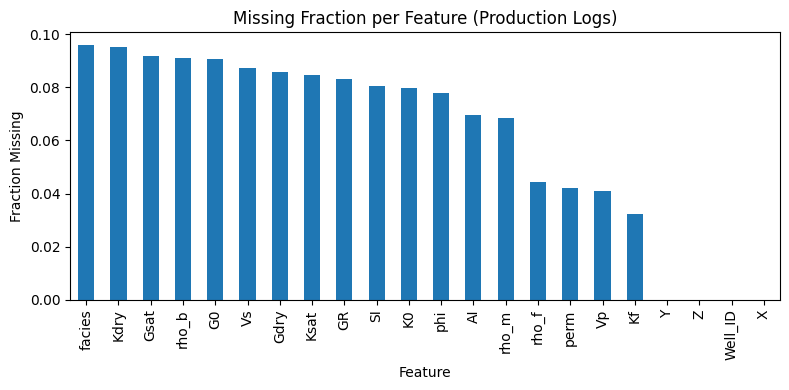

In [241]:
missing_frac = logs_prod.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
missing_frac.plot(kind="bar")
plt.title("Missing Fraction per Feature (Production Logs)")
plt.xlabel("Feature")
plt.ylabel("Fraction Missing")
plt.tight_layout()
plt.show()

# Imputations

We apply a simple, reproducible baseline, using median imputations

In [242]:
def impute_facies_by_well_depth(df: pd.DataFrame,
                                well_col="Well_ID",
                                depth_col="Z",
                                facies_col="facies") -> pd.DataFrame:
    df = df.copy()

    # Keep original row order for later restoration
    df["_row_id"] = np.arange(len(df))

    # Sort within-well by depth so "runs" are respected
    df = df.sort_values([well_col, depth_col]).reset_index(drop=True)

    # Primary: nearest-neighbor fill inside each well
    df[facies_col] = df.groupby(well_col)[facies_col].transform(lambda s: s.ffill().bfill())

    # Optional: if any NaNs remain (should be rare), fill by local neighbor mode
    # This matters only if an entire well's facies is missing (edge case).
    if df[facies_col].isna().any():
        def neighbor_mode_fill(s: pd.Series) -> pd.Series:
            arr = s.to_numpy()
            for i in range(len(arr)):
                if pd.isna(arr[i]):
                    left  = arr[i-1] if i-1 >= 0 else np.nan
                    right = arr[i+1] if i+1 < len(arr) else np.nan
                    candidates = [v for v in [left, right] if not pd.isna(v)]
                    if len(candidates) > 0:
                        # pick the most frequent candidate (ties resolve naturally)
                        arr[i] = pd.Series(candidates).mode().iloc[0]
            return pd.Series(arr, index=s.index)
        df[facies_col] = df.groupby(well_col)[facies_col].transform(neighbor_mode_fill)

    # Restore original order
    df = df.sort_values("_row_id").drop(columns=["_row_id"]).reset_index(drop=True)
    return df

In [243]:
def solve_rho_b_first(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1) rho_b from AI / Vp
    mask = df["rho_b"].isna() & df["AI"].notna() & df["Vp"].notna() & (df["Vp"] != 0)
    df.loc[mask, "rho_b"] = (df.loc[mask, "AI"] / df.loc[mask, "Vp"]) / 1000.0

    # 2) rho_b from SI / Vs
    mask = df["rho_b"].isna() & df["SI"].notna() & df["Vs"].notna() & (df["Vs"] != 0)
    df.loc[mask, "rho_b"] = (df.loc[mask, "SI"] / df.loc[mask, "Vs"]) / 1000.0

    # 3) rho_b from mixing law
    mask = (
        df["rho_b"].isna()
        & df["rho_f"].notna()
        & df["rho_m"].notna()
        & df["phi"].notna()
    )
    df.loc[mask, "rho_b"] = (
        df.loc[mask, "rho_f"] * df.loc[mask, "phi"]
        + df.loc[mask, "rho_m"] * (1.0 - df.loc[mask, "phi"])
    )

    return df

In [244]:
def solve_impedances_and_velocities(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rho_kg = df["rho_b"] * 1000.0

    # AI = rho * Vp
    mask = df["AI"].isna() & df["Vp"].notna() & rho_kg.notna()
    df.loc[mask, "AI"] = rho_kg[mask] * df.loc[mask, "Vp"]

    # Vp = AI / rho
    mask = df["Vp"].isna() & df["AI"].notna() & rho_kg.notna() & (rho_kg != 0)
    df.loc[mask, "Vp"] = df.loc[mask, "AI"] / rho_kg[mask]

    # SI = rho * Vs
    mask = df["SI"].isna() & df["Vs"].notna() & rho_kg.notna()
    df.loc[mask, "SI"] = rho_kg[mask] * df.loc[mask, "Vs"]

    # Vs = SI / rho
    mask = df["Vs"].isna() & df["SI"].notna() & rho_kg.notna() & (rho_kg != 0)
    df.loc[mask, "Vs"] = df.loc[mask, "SI"] / rho_kg[mask]

    return df

In [245]:
def solve_density_mixing(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # phi = (rho_m - rho_b)/(rho_m - rho_f)
    denom = df["rho_m"] - df["rho_f"]
    mask = (
        df["phi"].isna()
        & df["rho_b"].notna()
        & df["rho_m"].notna()
        & df["rho_f"].notna()
        & (denom != 0)
    )
    df.loc[mask, "phi"] = (df.loc[mask, "rho_m"] - df.loc[mask, "rho_b"]) / denom[mask]

    # rho_f = (rho_b - (1-phi) rho_m) / phi
    mask = (
        df["rho_f"].isna()
        & df["rho_b"].notna()
        & df["rho_m"].notna()
        & df["phi"].notna()
        & (df["phi"] != 0)
    )
    df.loc[mask, "rho_f"] = (
        df.loc[mask, "rho_b"]
        - (1.0 - df.loc[mask, "phi"]) * df.loc[mask, "rho_m"]
    ) / df.loc[mask, "phi"]

    # rho_m = (rho_b - phi rho_f) / (1 - phi)
    mask = (
        df["rho_m"].isna()
        & df["rho_b"].notna()
        & df["rho_f"].notna()
        & df["phi"].notna()
        & ((1.0 - df["phi"]) != 0)
    )
    df.loc[mask, "rho_m"] = (
        df.loc[mask, "rho_b"] - df.loc[mask, "phi"] * df.loc[mask, "rho_f"]
    ) / (1.0 - df.loc[mask, "phi"])

    return df

In [246]:
def structured_fallback_impute(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # columns you want to median-impute
    target_cols = ["rho_b", "AI", "SI", "Vp", "Vs", "facies", "rho_m", "rho_f", "phi"]

    # keep only ones that exist and are numeric
    num_cols = [
        c for c in target_cols
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
    ]

    # (well, facies)
    df[num_cols] = df.groupby(["Well_ID", "facies"])[num_cols].transform(
        lambda s: s.fillna(s.median())
    )

    # well
    df[num_cols] = df.groupby("Well_ID")[num_cols].transform(
        lambda s: s.fillna(s.median())
    )

    # global
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    return df

In [247]:
def full_imputes(df: pd.DataFrame) -> pd.DataFrame:
     df = df.copy()

     df = impute_facies_by_well_depth(df)
     df = solve_rho_b_first(df)
     df = solve_impedances_and_velocities(df)
     df = solve_density_mixing(df)

     return df

In [248]:
# Impute
logs_prod = full_imputes(logs_prod)
logs_pre = full_imputes(logs_pre)

In [249]:
# Fill remaining with median

logs_prod = structured_fallback_impute(logs_prod)
logs_pre = structured_fallback_impute(logs_pre)
num_cols = [c for c in logs_prod.select_dtypes(include="number").columns if c != "Well_ID"]
print("Remaining NaNs (prod):", int(logs_prod[num_cols].isna().sum().sum()))
print("Remaining NaNs (pre): ", int(logs_pre[num_cols].isna().sum().sum()))

Remaining NaNs (prod): 1022
Remaining NaNs (pre):  165


### Facies-based hierarchical imputation (within-well → global)

For properties correlated with facies (Kf, K0, G0, Kdry), we impute missing values using a hierarchical approach:
1) median within the same well and facies
2) median across all wells for that facies
3) global median as a final fallback

In [250]:
def facies_well_impute(
    df: pd.DataFrame,
    cols=("K0", "G0", "Kf", "GR"),
    well_col: str = "Well_ID",
    facies_col: str = "facies",
    use_median: bool = True
) -> pd.DataFrame:
    """
    Hierarchical imputation (only for selected columns):
      1) (Well, Facies)
      2) (Facies)
      3) Global

    Parameters
    ----------
    df : DataFrame
    cols : iterable of column names to impute
    use_median : if False, uses mean instead
    """

    df = df.copy()
    stat = "median" if use_median else "mean"

    # only keep numeric columns that actually exist
    cols = [
        c for c in cols
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
    ]

    for col in cols:
        # Level 1: within well & facies
        df[col] = df.groupby([well_col, facies_col])[col].transform(
            lambda s: s.fillna(getattr(s, stat)())
        )

        # Level 2: facies-wide
        df[col] = df.groupby(facies_col)[col].transform(
            lambda s: s.fillna(getattr(s, stat)())
        )

        # Level 3: global
        fill_value = getattr(df[col], stat)()
        df[col] = df[col].fillna(fill_value)

    return df

In [251]:
def impute_sat_and_dry_with_physics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # -------------------------------------------------
    # Step 1: Copy dry <-> sat (identity)
    # -------------------------------------------------

    # Gsat missing but Gdry exists
    mask = df["Gsat"].isna() & df["Gdry"].notna()
    df.loc[mask, "Gsat"] = df.loc[mask, "Gdry"]

    # -------------------------------------------------
    # Step 2: Physics fill for remaining Gsat
    # Gsat = rho_b * Vs^2 / 1e6
    # -------------------------------------------------

    mask = (
        df["Gsat"].isna()
        & df["rho_b"].notna()
        & df["Vs"].notna()
    )

    df.loc[mask, "Gsat"] = (
        df.loc[mask, "rho_b"] * (df.loc[mask, "Vs"] ** 2)
    ) / 1e6  # Units GPa

    # Ensure Gdry matches (identity)
    mask = df["Gdry"].isna() & df["Gsat"].notna()
    df.loc[mask, "Gdry"] = df.loc[mask, "Gsat"]

    # -------------------------------------------------
    # Step 3: Physics fill for remaining Ksat
    # Ksat = rho_b * (Vp^2 - 4/3 * Vs^2) / 1e6
    # -------------------------------------------------

    mask = (
        df["Ksat"].isna()
        & df["rho_b"].notna()
        & df["Vs"].notna()
        & df["Vp"].notna()
    )

    df.loc[mask, "Ksat"] = (
        df.loc[mask, "rho_b"] * ((df.loc[mask, "Vp"] ** 2) -4/3 * (df.loc[mask, "Vs"] ** 2))
    ) / 1e6  # Units GPa

    # -------------------------------------------------
    # Step 4: Physics fill for remaining Kdry
    # Kdry = K0 / (1 + 1/(Ksat/(K0 - Ksat) - Kf/(phi(K0 - Kf))))
    # -------------------------------------------------

    mask = (
        df["Kdry"].isna()
        & df["Ksat"].notna()
        & df["K0"].notna()
        & df["Kf"].notna()
        & df["phi"].notna()
    )

    df.loc[mask, "Kdry"] =  df.loc[mask, "K0"]/(
        1 + 1/(
            df.loc[mask, "Ksat"]/(df.loc[mask, "K0"] - df.loc[mask, "Ksat"]) - df.loc[mask, "Kf"]/(df.loc[mask, "phi"]*(df.loc[mask, "K0"] - df.loc[mask, "Kf"]))
            )
    )

    return df

In [252]:
logs_prod = facies_well_impute(logs_prod)
logs_pre = facies_well_impute(logs_pre)
logs_prod = impute_sat_and_dry_with_physics(logs_prod)
logs_pre = impute_sat_and_dry_with_physics(logs_pre)

### Permeability imputation (facies- and depth-aware)

Permeability exhibits strong facies dependence and log-normal behavior.
Missing values are imputed by interpolating in log-space within each
(Well_ID, facies) interval. Remaining gaps are filled using facies-based
and global medians as fallback.

In [253]:
def impute_perm(df: pd.DataFrame,
                well_col: str = "Well_ID",
                facies_col: str = "facies",
                perm_col: str = "perm") -> pd.DataFrame:
    df = df.copy()
    df["_row_id"] = np.arange(len(df))

    # Work only on valid positive permeability
    valid = df[perm_col] > 0
    df.loc[valid, "_log_perm"] = np.log(df.loc[valid, perm_col])

    # Sort for depth-wise interpolation
    df = df.sort_values([well_col, facies_col])

    # 1) Interpolate in log-space within (well, facies)
    df["_log_perm"] = (
        df.groupby([well_col, facies_col])["_log_perm"]
          .transform(lambda s: s.interpolate(limit_direction="both"))
    )

    # 2) Fill remaining via (well, facies) median
    df["_log_perm"] = (
        df.groupby([well_col, facies_col])["_log_perm"]
          .transform(lambda s: s.fillna(s.median()))
    )

    # 3) Fill remaining via facies median
    df["_log_perm"] = (
        df.groupby(facies_col)["_log_perm"]
          .transform(lambda s: s.fillna(s.median()))
    )

    # 4) Global fallback
    df["_log_perm"] = df["_log_perm"].fillna(df["_log_perm"].median())

    # Back-transform
    df[perm_col] = np.exp(df["_log_perm"])

    # Cleanup
    df = df.sort_values("_row_id")
    df = df.drop(columns=["_row_id", "_log_perm"])

    return df

In [254]:
logs_prod = impute_perm(logs_prod)
logs_pre = impute_perm(logs_pre)

#num_cols = [c for c in logs_prod.select_dtypes(include="number").columns if c != "Well_ID"]
print("Remaining NaNs (prod):\n", logs_prod.isna().sum().sort_values(ascending=False), "\n")
print("Remaining NaNs (pre):\n", logs_pre.isna().sum().sort_values(ascending=False))

Remaining NaNs (prod):
 Well_ID    0
X          0
Y          0
Z          0
AI         0
SI         0
Vp         0
Vs         0
rho_b      0
rho_f      0
rho_m      0
K0         0
Kdry       0
Kf         0
Ksat       0
G0         0
Gdry       0
Gsat       0
facies     0
phi        0
perm       0
GR         0
dtype: int64 

Remaining NaNs (pre):
 Well_ID    0
X          0
Y          0
Z          0
AI         0
SI         0
Vp         0
Vs         0
rho_b      0
rho_f      0
rho_m      0
K0         0
Kdry       0
Kf         0
Ksat       0
G0         0
Gdry       0
Gsat       0
facies     0
phi        0
perm       0
GR         0
dtype: int64


# Distribution Visualizations

To ensure that our imputation is valid, we can visualize the results for the following:
 - **phi**: bounded, usually skewed
 - **perm**: extremely skewed, should be easy to check if imputation causes spikes or incorrect flattening
 - **GR**: smooth, should not look overly spiky

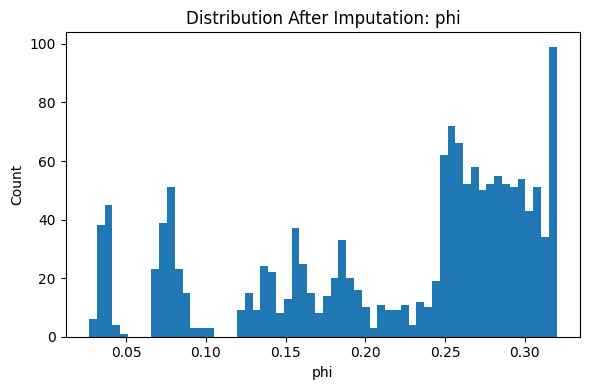

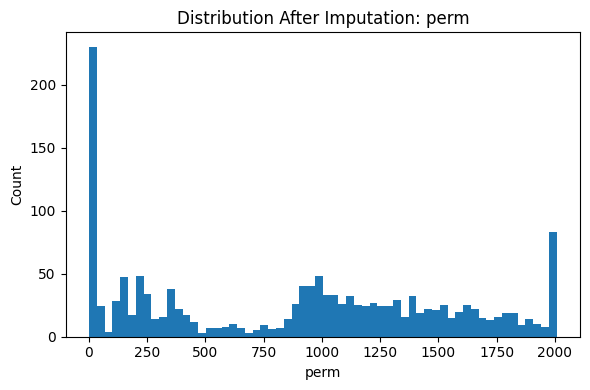

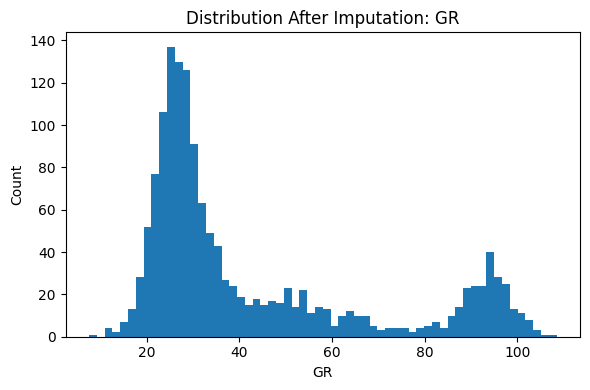

In [255]:
for feat in ["phi", "perm", "GR"]:
    plt.figure(figsize=(6, 4))
    plt.hist(logs_prod[feat].values, bins=60)
    plt.title(f"Distribution After Imputation: {feat}")
    plt.xlabel(feat)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

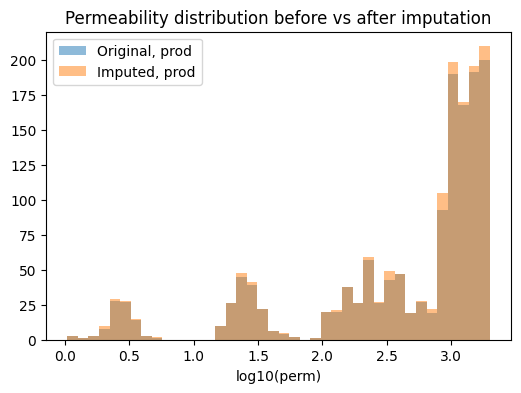

In [256]:
plt.figure(figsize=(6,4))
#plt.hist(np.log10(logs_pre_og["perm"].dropna()), bins=40, alpha=0.5, label="Original, pre")
plt.hist(np.log10(logs_prod_og["perm"].dropna()), bins=40, alpha=0.5, label="Original, prod")
#plt.hist(np.log10(logs_pre["perm"]), bins=40, alpha=0.5, label="Imputed, pre")
plt.hist(np.log10(logs_prod["perm"]), bins=40, alpha=0.5, label="Imputed, prod")
plt.legend()
plt.xlabel("log10(perm)")
plt.title("Permeability distribution before vs after imputation")
plt.show()

In [257]:
logs_prod.to_csv("Well_log_data_production_wells_imputed.csv", index=False)
logs_pre.to_csv("Well_log_data_preproduction_wells_imputed.csv", index=False)

#Data Aggregation & Feature Selection *via* Mutual Information
- Data must be **aggregated** so that the model input and output (3-year cumulative predictions per well) data are at the same resolution (per well).
- Mutual information is preferred over correlation to determine the most powerful predictive features to include in our model due to its ability to treat **non-linear** and **heteroskedastic** distributions, which are prevalent in geostatistics.


First, we will **aggregate** the data by well.

In [258]:
logs_prod_agg = logs_prod.copy() #already imputed
logs_pre_agg = logs_pre.copy()
#Creating a log_mean function that transforms permeability data into a more useful form
def log_mean(x):
    x = x[x > 0]
    if len(x) == 0:
        return np.nan
    return np.exp(np.mean(np.log(x)))

#Compiling aggregate features using relevant descriptors
agg_dict = {
    "phi": ["mean", "median"],
    "perm": log_mean,
    "rho_b": "mean",
    "Vp": "mean",
    "Vs": "mean",
    "Ksat": "mean",
    "Gsat": "mean",
    "GR": ["mean", lambda x: np.percentile(x, 75)]
}

well_prod_agg = logs_prod_agg.groupby("Well_ID").agg(agg_dict)
well_pre_agg = logs_pre_agg.groupby("Well_ID").agg(agg_dict)
well_prod_agg.columns = [
    "phi_mean", "phi_median",
    "perm_logmean",
    "rho_b_mean",
    "Vp_mean",
    "Vs_mean",
    "Ksat_mean",
    "Gsat_mean",
    "GR_mean",
    "GR_p75"
]
well_pre_agg.columns = [
    "phi_mean", "phi_median",
    "perm_logmean",
    "rho_b_mean",
    "Vp_mean",
    "Vs_mean",
    "Ksat_mean",
    "Gsat_mean",
    "GR_mean",
    "GR_p75"
]
facies_frac = (
    logs_prod_agg.groupby("Well_ID")["facies"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
)

facies_prod_frac = (
    logs_prod_agg.groupby("Well_ID")["facies"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
)
facies_pre_frac = (
    logs_pre_agg.groupby("Well_ID")["facies"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
)

facies_prod_frac.columns = [f"facies_frac_{int(c)}" for c in facies_prod_frac.columns]
input_prod_wells = well_prod_agg.join(facies_prod_frac)
facies_pre_frac.columns = [f"facies_frac_{int(c)}" for c in facies_pre_frac.columns]
input_pre_wells = well_pre_agg.join(facies_pre_frac)
input_pre_wells = input_pre_wells.reindex(
    columns=input_prod_wells.columns,
    fill_value=0
)

In [259]:
#Adding the sand proportion at a given (x,y) as a descriptor.

def sample_sand_at_well(x, y, sand_map,
                        x_min, x_max,
                        y_min, y_max):
    """
    Sample sand proportion at a well location.
    """
    nx, ny = sand_map.shape

    ix = int((x - x_min) / (x_max - x_min) * (nx - 1))
    iy = int((y - y_min) / (y_max - y_min) * (ny - 1))

    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)

    return sand_map[ix, iy]

# Get well coordinates (one row per well)
well_prod_xy = (
    logs_prod.groupby("Well_ID")[["X", "Y"]]
    .first()
)

# Bounding box from wells
x_min, x_max = well_prod_xy["X"].min(), well_prod_xy["X"].max()
y_min, y_max = well_prod_xy["Y"].min(), well_prod_xy["Y"].max()

# Sample sand map
well_prod_xy["sand_prop"] = well_prod_xy.apply(
    lambda r: sample_sand_at_well(
        r["X"], r["Y"],
        sand_map,
        x_min, x_max,
        y_min, y_max
    ),
    axis=1
)

well_pre_xy = (
    logs_pre.groupby("Well_ID")[["X", "Y"]]
    .first()
)

# Bounding box from wells
x_min, x_max = well_pre_xy["X"].min(), well_pre_xy["X"].max()
y_min, y_max = well_pre_xy["Y"].min(), well_pre_xy["Y"].max()

# Sample sand map
well_pre_xy["sand_prop"] = well_pre_xy.apply(
    lambda r: sample_sand_at_well(
        r["X"], r["Y"],
        sand_map,
        x_min, x_max,
        y_min, y_max
    ),
    axis=1
)

input_prod_wells = input_prod_wells.join(well_prod_xy["sand_prop"])
input_prod_wells.head(13)
input_pre_wells = input_pre_wells.join(well_pre_xy["sand_prop"])
input_pre_wells.head(13)


,phi_mean,phi_median,perm_logmean,rho_b_mean,Vp_mean,Vs_mean,Ksat_mean,Gsat_mean,GR_mean,GR_p75,facies_frac_1,facies_frac_2,facies_frac_3,facies_frac_4,facies_frac_5,facies_frac_6,sand_prop
Well_ID,,,,,,,,,,,,,,,,,
72,0.203770,0.243273,449.645034,2.297263,2266.490839,1058.208601,8.664690,2.654813,42.652655,57.187480,0.000000,0.476190,0.285714,0.190476,0.047619,0.000000,0.624005
73,0.254681,0.262791,902.370064,2.205257,1996.519310,940.638600,6.346048,2.023150,29.085635,32.939265,0.000000,0.904762,0.095238,0.000000,0.000000,0.000000,0.623175
74,0.217408,0.256851,303.553873,2.278727,2227.251959,995.809828,9.333798,2.425501,40.515833,44.753636,0.000000,0.761905,0.000000,0.000000,0.000000,0.238095,0.624259
75,0.297240,0.302693,1573.934843,2.136311,1856.793126,840.103750,5.360487,1.513894,26.982888,30.396179,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.623579
76,0.232086,0.255653,661.319592,2.247879,2132.898587,994.750254,7.534166,2.312947,37.109876,49.866794,0.000000,0.714286,0.190476,0.095238,0.000000,0.000000,0.623380
77,0.209621,0.243025,380.953619,2.289711,2325.207523,1098.885738,9.124523,2.790356,42.801224,38.382335,0.809524,0.000000,0.000000,0.000000,0.142857,0.047619,0.623095
78,0.109266,0.076267,41.073588,2.474354,2870.461286,1257.720225,15.430163,3.980740,74.975120,96.359561,0.000000,0.000000,0.238095,0.095238,0.428571,0.238095,0.623868
79,0.167623,0.159087,192.058097,2.367615,2505.617776,1097.274284,11.500095,2.927765,60.281877,81.559595,0.000000,0.238095,0.238095,0.190476,0.333333,0.000000,0.623008
80,0.108353,0.079368,41.301064,2.476966,2855.717787,1223.924300,15.529159,3.766404,77.072732,93.360110,0.000000,0.000000,0.238095,0.190476,0.333333,0.238095,0.623958


## Feature Construction and Selection Rationale

The target variable (three-year cumulative oil production) is defined at the well level, while the available petrophysical and geophysical data are measured along the wellbore. To avoid target leakage and ensure consistent model resolution, all depth-indexed features were aggregated into physically meaningful well-level descriptors.

### Aggregation Strategy

For continuous properties, aggregation statistics were chosen based on the physical behavior and statistical distribution of each variable:

- **Porosity (phi)**: mean and median values were used to represent effective storage capacity and robustness to outliers.
- **Permeability (perm)**: permeability exhibits log-normal behavior, so a log-space mean was used to preserve scale and avoid bias from extreme values.
- **Elastic/density-related properties (rho_b, Vp, Vs, Ksat, Gsat)**: arithmetic means were used to represent effective elastic response along the producing interval.
- **Gamma Rays (GR)**: mean GR captures overall shale content, while the 75th percentile highlights shale-rich intervals that may impact flow and production.

### Facies Representation

Lithology was incorporated through **facies proportions**, computed as the fraction of each facies encountered within a well. This preserves categorical geological information without introducing unnecessary depth-level leakage.

### Spatial Context

A low-resolution seismic-derived sand proportion map was included as a single spatial descriptor per well by sampling the map at each well location. This provides regional depositional context while limiting model complexity.

### Feature Selection

Initial feature screening is to be performed (below) using **mutual information**, which captures both linear and nonlinear dependencies between descriptors and cumulative production without assuming normality or homoskedasticity. This approach is well-suited for tree-based models and small datasets.

Overall, the resulting feature set balances physical interpretability, statistical robustness, and predictive relevance while minimizing overfitting risk!


Next, we will load the **production history** so that we have data to a) rank features and construct our model and b) train our model on.

In [260]:
prod = pd.read_csv(
    "Production_history_production_wells.csv",
    parse_dates=["Date"]
)

start = pd.Timestamp("2019-01-01")
end_36 = pd.Timestamp("2022-01-01")

def cum_at_or_before(df, t):
    df = df[df["Date"] <= t]
    if df.empty:
        return None
    return df.sort_values("Date").iloc[-1]["Cumulative Oil Production, BBL"]

targets = []

for well_id, g in prod.groupby("Well_ID"):
    c36 = cum_at_or_before(g, end_36)
    if c36 is not None:
        targets.append({
            "Well_ID": well_id,
            "cum_oil_36mo": c36
        })

y_df = pd.DataFrame(targets).set_index("Well_ID")
input_prod_wells = input_prod_wells.join(y_df, how="inner")

x_prod = input_prod_wells.drop(columns="cum_oil_36mo")
y = input_prod_wells["cum_oil_36mo"]
x_pre = input_pre_wells.copy()


Now, we can calculate mutual information to understand feature relevance.

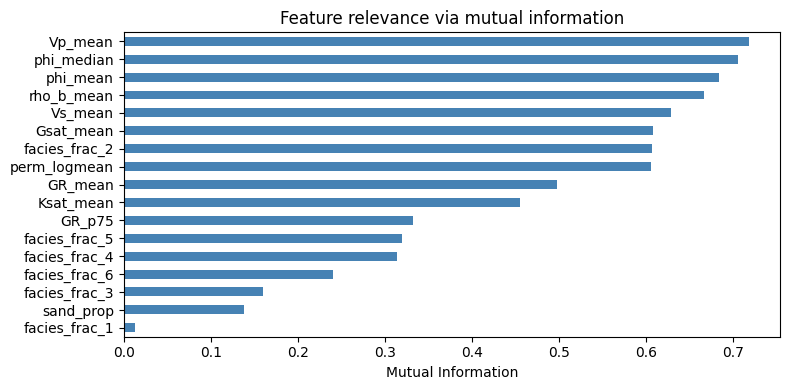

In [261]:
# MI benefits from roughly scaled inputs
Xs = StandardScaler().fit_transform(x_prod)
Xs_pre = StandardScaler().fit_transform(x_pre)

mi = mutual_info_regression(Xs, y, random_state=42)

mi_scores = (
    pd.Series(mi, index=x_prod.columns)
      .sort_values(ascending=False)
)

mi_scores


plt.figure(figsize=(8,4))
mi_scores.sort_values(ascending=True).plot(
    kind="barh",
    color="steelblue"
)
plt.xlabel("Mutual Information")
plt.title("Feature relevance via mutual information")
plt.tight_layout()
plt.show()

#More Data Visualization
Some univariate and bivariate plots show the relationship between relevant features and cumulative oil production.

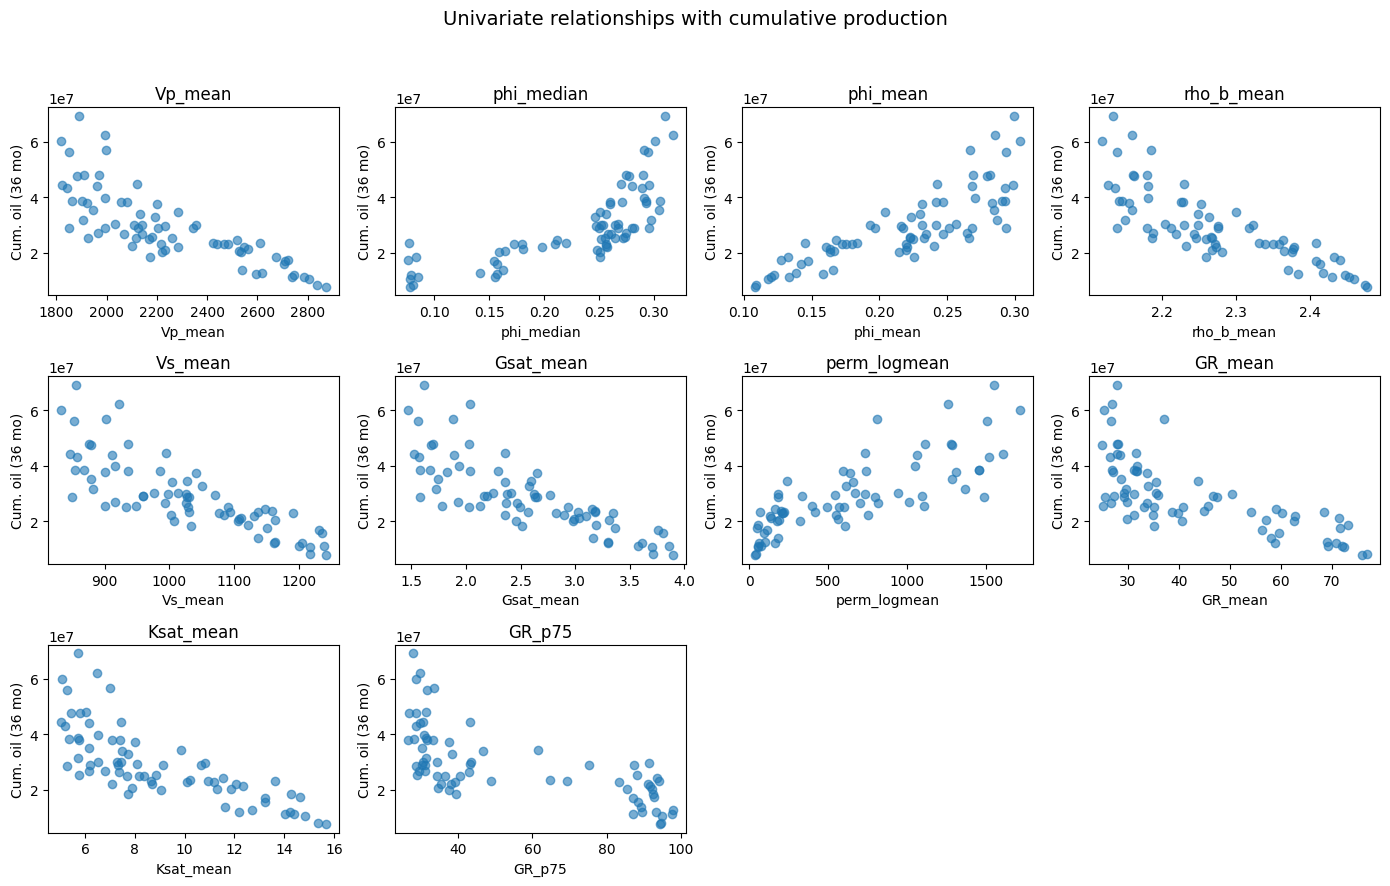

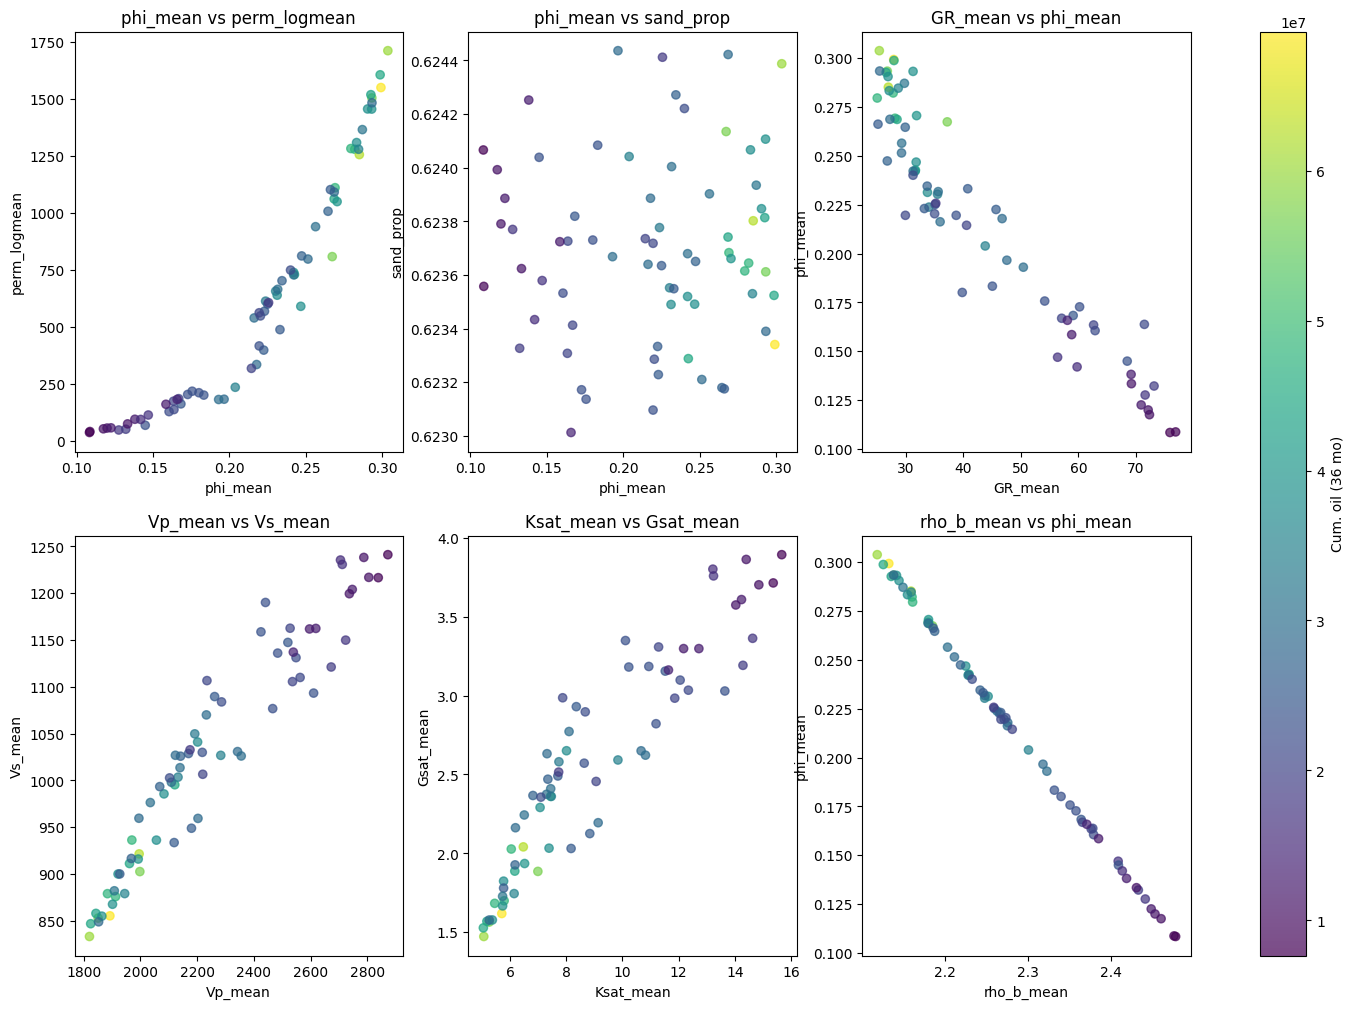

In [262]:
top_feats = mi_scores.head(12).index.tolist()
# Filter top_feats to ensure all elements are actual columns in x
top_feats = [feat for feat in top_feats if feat in x.columns]

#Univariate Plots
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.flatten()

for ax, feat in zip(axes, top_feats):
    ax.scatter(x[feat], y, alpha=0.6)
    ax.set_xlabel(feat)
    ax.set_ylabel("Cum. oil (36 mo)")
    ax.set_title(feat)

# Hide any unused axes
for ax in axes[len(top_feats):]:
    ax.axis("off")

plt.suptitle("Univariate relationships with cumulative production", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#Bivariate Plots
pairs = [
    ("phi_mean", "perm_logmean"),
    ("phi_mean", "sand_prop"),
    ("GR_mean", "phi_mean"),
    ("Vp_mean", "Vs_mean"),
    ("Ksat_mean", "Gsat_mean"),
    ("rho_b_mean", "phi_mean"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, (xcol, ycol) in zip(axes, pairs):
    sc = ax.scatter(
        x[xcol], x[ycol],
        c=y, cmap="viridis", alpha=0.7
    )
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{xcol} vs {ycol}")

fig.colorbar(sc, ax=axes, label="Cum. oil (36 mo)")
plt.show()

We will try a model with the top 15 features now as a first pass. Because we are using a decision tree-based model, weaker predictors should not affect the model so much. With many features, we can prevent overfitting by limiting the model depth (to 3).

In [263]:
selected_features = mi_scores.head(15).index.tolist() #15 features in model
x_prod_sel = x_prod[selected_features]
x_pre_sel = x_pre[selected_features]
x_train, x_test, y_train, y_test = train_test_split(
    x_prod_sel, y,
    test_size=0.2, #20% of data left for testing
    random_state=42
)

#Instantiate XGBoost Model

In [264]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=3, #avoid overfitting
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

#5-Fold Cross Validation
We will be using 5-fold CV to train and test the data. Essentially, the data will get segmented into five equally-sized parts. Since we will use 80% of the data for training, then 20% will be left for testing. Of this 80%, 80% (64% globally) will be used each time for training (basically 4 of the 5 parts) and one for testing. Each "fold," the group being tested on will rotate.

In [265]:
base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=500  # we'll tune how strong it is via learning_rate + depth
)

param_dist = {
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_lambda": [0.0, 0.5, 1.0, 2.0, 5.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base,
    param_distributions=param_dist,
    n_iter=40,  # 30–60 is fine
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(x_train, y_train)

print("Best CV RMSE:", -search.best_score_)
print("Best params:", search.best_params_)
best_model = search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV RMSE: 7304698.1685895175
Best params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


Test RMSE: 10350266.56522399
Test RMSE: 10350266.56522399
Test MAE : 8014823.2


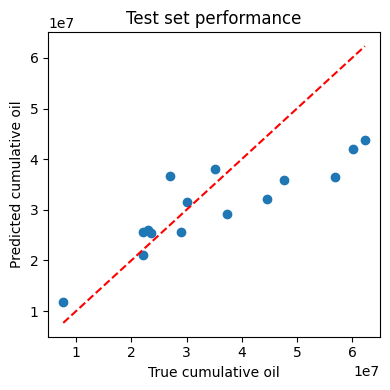

In [266]:
best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
from sklearn.metrics import mean_squared_error


print("Test RMSE:", rmse)
print("Test RMSE:", rmse)
print("Test MAE :", mae)

plt.figure(figsize=(4,4))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.xlabel("True cumulative oil")
plt.ylabel("Predicted cumulative oil")
plt.title("Test set performance")
plt.tight_layout()
plt.show()

Final model with tuned hyperparameters

In [267]:
final_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=500,
    **search.best_params_
)

final_model.fit(x_prod_sel, y)  # X_sel is ALL labeled wells, y is ALL labels

best_params = search.best_params_

final_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    max_depth=best_params["max_depth"],
    learning_rate=best_params["learning_rate"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    min_child_weight=best_params["min_child_weight"],
    reg_alpha=best_params["reg_alpha"],
    reg_lambda=best_params["reg_lambda"],
    random_state=42
)

final_model.fit(x_sel, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

#Bootstrapping

In [268]:
n_boot = 100
n_pre  = x_pre_sel.shape[0]

boot_preds = np.zeros((n_boot, n_pre))

for i in range(n_boot):
    # resample wells
    x_b, y_b = resample(
        x_prod_sel, y,
        replace=True,
        random_state=42 + i
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        max_depth=best_params["max_depth"],
        learning_rate=best_params["learning_rate"],
        subsample=best_params["subsample"],
        colsample_bytree=best_params["colsample_bytree"],
        min_child_weight=best_params["min_child_weight"],
        reg_alpha=best_params["reg_alpha"],
        reg_lambda=best_params["reg_lambda"],
        random_state=42 + i
    )

    model.fit(x_b, y_b)
    boot_preds[i, :] = model.predict(x_pre_sel)

#Updating the Solution

In [269]:
df = pd.read_csv("solution.csv")  # template
estimate = boot_preds.mean(axis=0)
realizations = boot_preds.T
df["Prediction_BBL"] = estimate

for k in range(100):
    df[f"R{k+1}"] = realizations[:, k]

df.to_csv("solution.csv", index=False)